In [6]:
import pandas as pd
from pathlib import Path
from git_root import git_root

df = pd.read_csv(git_root("causality/data/learning_mindset.csv"))
outcome_column = "achievement_score"
treatment_column = "intervention"
feature_columns = [
    column
    for column in df.columns
    if column not in [outcome_column, treatment_column]
]
categorical_feature_columns = [
    "ethnicity",
    "gender",
    "frst_in_family",
    "school_urbanicity",
    "schoolid",
]
# Note that explicitly setting the dtype of these features to category
# allows both lightgbm as well as shap plots to
# 1. Operate on features which are not of type int, bool or float
# 2. Correctly interpret categoricals with int values to be
#    interpreted as categoricals, as compared to ordinals/numericals.
for categorical_feature_column in categorical_feature_columns:
    df[categorical_feature_column] = df[categorical_feature_column].astype(
        "category"
    )

In [ ]:
df

# S-Learner

In [45]:
from lightgbm import LGBMRegressor
from metalearners import SLearner

slearner = SLearner(
    is_classification=False,
    n_variants=2,
    nuisance_model_factory=LGBMRegressor,
    treatment_model_factory=LGBMRegressor,
    propensity_model_factory=LGBMRegressor,
    nuisance_model_params={"n_estimators": 10, "verbose": -1},
    propensity_model_params={"n_estimators": 8, "verbose": -1},
    treatment_model_params={"n_estimators": 3, "verbose": -1},
)

slearner.fit(
    X=df[feature_columns],
    y=df[outcome_column],
    w=df[treatment_column]
)

cate_estimates_slearner = slearner.predict(
    X=df[feature_columns],
    is_oos=False
)

is_classifier
is_regressor


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


# T-Learner

### Instantiate

In [12]:
from metalearners import TLearner
from lightgbm import LGBMRegressor

tlearner = TLearner(
    nuisance_model_factory=LGBMRegressor,
    is_classification=False,
    n_variants=2,
    nuisance_model_params={"verbose": -1}
)

is_classifier
is_regressor


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


### Fit and predict on same dataset

In [44]:
tlearner.fit(
    X=df[feature_columns],
    y=df[outcome_column],
    w=df[treatment_column]
)

cate_estimates_tlearner = tlearner.predict(
    X=df[feature_columns],
    is_oos=False
)

### Display simple results

In [15]:
from metalearners.utils import simplify_output
import numpy as np
one_d_estimates = simplify_output(cate_estimates_tlearner)
one_d_estimates = np.ravel(cate_estimates_tlearner)
print(cate_estimates_tlearner.shape)
print(one_d_estimates.shape)

(10391, 1, 1)
(10391,)


In [19]:
one_d_estimates.mean()

np.float64(0.3832345502839683)

In [20]:
one_d_estimates.var()

np.float64(0.16073641299020916)

### Test for significant treatment effect

In [ ]:
from scipy import stats

t_stat, p_value = stats.ttest_1samp(one_d_estimates, 0)
print(f"t-statistic: {t_stat}, p-value: {p_value}")

t-statistic: 97.43506816956516, p-value: 0.0


# R-Learner

In [29]:
from metalearners import RLearner
from lightgbm import LGBMClassifier
rlearner = RLearner(
    nuisance_model_factory=LGBMRegressor,
    propensity_model_factory=LGBMClassifier,
    treatment_model_factory=LGBMRegressor,
    is_classification=False,
    n_variants=2,
    nuisance_model_params={"n_estimators": 10, "verbose": -1},
    propensity_model_params={"n_estimators": 8, "verbose": -1},
    treatment_model_params={"n_estimators": 3, "verbose": -1},
)

is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor


In [40]:
rlearner.fit(
    X=df[feature_columns],
    y=df[outcome_column],
    w=df[treatment_column],
)

cate_estimates_rlearner = rlearner.predict(
    X=df[feature_columns],
    is_oos=False,
)

# X-Learner

In [36]:
from metalearners import XLearner

xlearner = XLearner(
    nuisance_model_factory=LGBMRegressor,
    propensity_model_factory=LGBMClassifier,
    treatment_model_factory=LGBMRegressor,
    is_classification=False,
    n_variants=2,
    nuisance_model_params={"n_estimators": 10, "verbose": -1},
    propensity_model_params={"n_estimators": 8, "verbose": -1},
    treatment_model_params={"n_estimators": 3, "verbose": -1},
)

is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/base.py:1270: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


In [39]:
xlearner.fit(
    X=df[feature_columns],
    y=df[outcome_column],
    w=df[treatment_column],
)

cate_estimates_xlearner = xlearner.predict(
    X=df[feature_columns],
    is_oos=False,
)

# Compare results

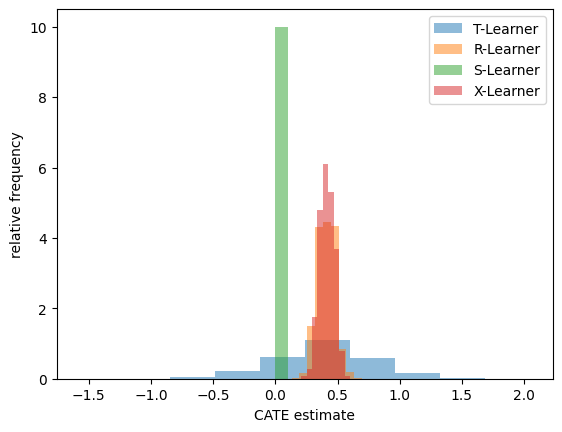

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(simplify_output(cate_estimates_tlearner), density=True, alpha=.5, label="T-Learner")
ax.hist(simplify_output(cate_estimates_rlearner), density=True, alpha=.5, label="R-Learner")
ax.hist(simplify_output(cate_estimates_slearner), density=True, alpha=.5, label="S-Learner")
ax.hist(simplify_output(cate_estimates_xlearner), density=True, alpha=.5, label="X-Learner")
ax.legend()
ax.set_xlabel("CATE estimate")
ax.set_ylabel("relative frequency")
plt.show()

In [56]:
results = pd.concat([pd.Series(np.ravel(cate_estimates_rlearner)), pd.Series(np.ravel(cate_estimates_slearner)), pd.Series(np.ravel(cate_estimates_tlearner)), pd.Series(np.ravel(cate_estimates_xlearner))], axis=1)

TypeError: _AxesBase.__init__() missing 1 required positional argument: 'fig'

In [57]:
results.columns = ["R", "S", "T", "X"]

In [62]:
results.iloc[np.argmax(results.X)]

R    0.559574
S    0.000000
T    1.745385
X    0.645147
Name: 1740, dtype: float64

In [64]:
df.iloc[1740]

schoolid                  39.000000
intervention               1.000000
achievement_score          0.529112
success_expect             7.000000
ethnicity                 10.000000
gender                     1.000000
frst_in_family             0.000000
school_urbanicity          2.000000
school_mindset            -0.425742
school_achievement         0.905764
school_ethnic_minority    -0.133119
school_poverty             1.055107
school_size               -1.145440
Name: 1740, dtype: float64